In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft
from scipy.linalg import logm
from scipy.linalg import ishermitian
from scipy.sparse.linalg import expm, expm_multiply

In [16]:
# n = 100
# h = 1/n
# T = 0.2
# num_time_points = 30
# t_vals = np.linspace(0, T, num_time_points)
# A = np.zeros((n,n), dtype=np.complex128)

# for i in range(n):
#     A[i,i] = - (1.2) /h
#     A[(i+1)%n,i] = (1.2) /h
#     # A[i,i] = 0#np.pi * np.cos(2 * np.pi * (i/n))

# print(A)

# # plt.matshow(A.imag)
# # plt.show()
# x = np.linspace(0, 1, n, endpoint=False)

# psi_0 = (x <= 0.4) * (x >= 0.2)
# plt.plot(x, psi_0)

# psi = expm_multiply(A, psi_0, start=0, stop=T, num=num_time_points)

# for i in range(num_time_points):
#     # plt.plot(x, psi[i].imag)
#     plt.plot(x, psi[i])

[[    3.14159265+0.j -1231.94158773+0.j     0.        +0.j ...
      0.        +0.j     0.        +0.j  1225.65841227+0.j]
 [ 1231.94158773+0.j     3.14153351+0.j -1238.2246449 +0.j ...
      0.        +0.j     0.        +0.j     0.        +0.j]
 [    0.        +0.j  1238.2246449 +0.j     3.1413561 +0.j ...
      0.        +0.j     0.        +0.j     0.        +0.j]
 ...
 [    0.        +0.j     0.        +0.j     0.        +0.j ...
      3.14106041+0.j -1213.09265276+0.j     0.        +0.j]
 [    0.        +0.j     0.        +0.j     0.        +0.j ...
   1213.09265276+0.j     3.1413561 +0.j -1219.3753551 +0.j]
 [-1225.65841227+0.j     0.        +0.j     0.        +0.j ...
      0.        +0.j  1219.3753551 +0.j     3.14153351+0.j]]


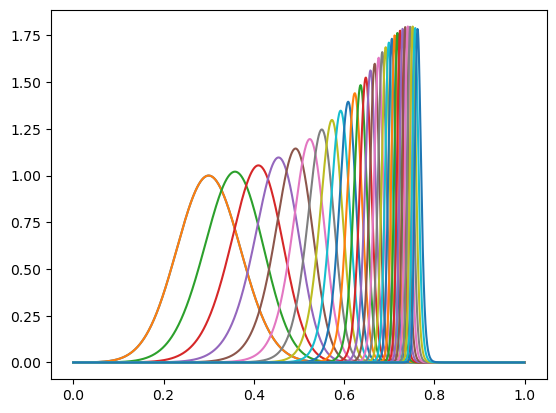

In [7]:
n = 1024
h = 1/n
T = 0.4
num_time_points = 30
t_vals = np.linspace(0, T, num_time_points)
A = np.zeros((n,n), dtype=np.complex128)

for i in range(n):
    A[i,(i+1)%n] = - (1.2+ np.sin(2 * np.pi * (i+1/2)/n)) /h
    A[(i+1)%n,i] = (1.2 + np.sin(2 * np.pi * (i+1/2)/n)) /h
    A[i,i] = np.pi * np.cos(2 * np.pi * (i/n))

print(A)

# plt.matshow(A.imag)
# plt.show()
x = np.linspace(0, 1, n, endpoint=False)

psi_0 = np.exp(-((x - 0.3)/0.1) ** 2)
plt.plot(x, psi_0)

psi = expm_multiply(A, psi_0, start=0, stop=T, num=num_time_points)

for i in range(num_time_points):
    # plt.plot(x, psi[i].imag)
    plt.plot(x, psi[i])

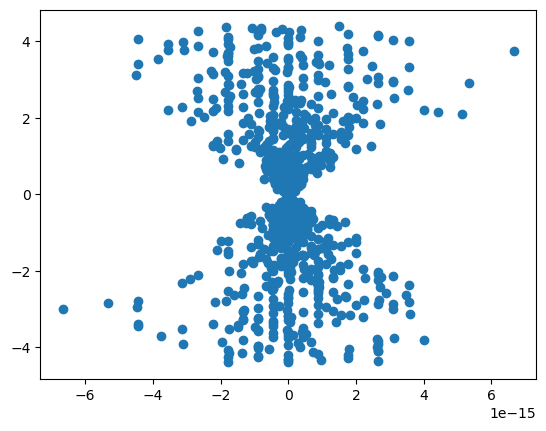

In [202]:
evals, evecs = np.linalg.eig(A * h)
plt.scatter(evals.real, evals.imag)

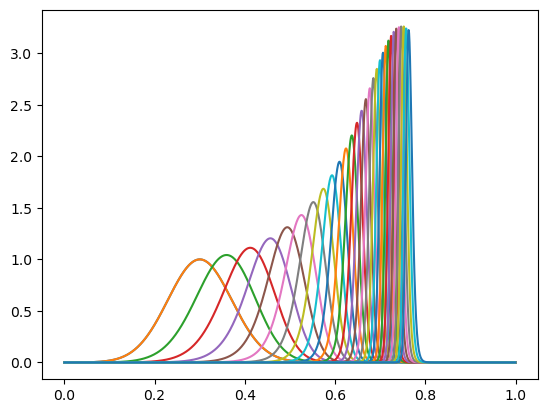

In [201]:
n = 1024
h = 1/n
T = 0.4
num_time_points = 30
t_vals = np.linspace(0, T, num_time_points)
A = np.zeros((n,n), dtype=np.complex128)

for i in range(n):
    A[i,(i+1)%n] = - (1.2 + np.sin(2 * np.pi * (i+1/2)/n)) /h
    A[(i+1)%n,i] = (1.2 + np.sin(2 * np.pi * (i+1/2)/n)) /h
    # A[i,i] = np.pi * np.cos(2 * np.pi * (i/n))

# plt.matshow(A.imag)
# plt.show()
x = np.linspace(0, 1, n, endpoint=False)

psi_0 = np.exp(-((x - 0.3)/0.1) ** 2)
plt.plot(x, psi_0)

psi = expm_multiply(A, psi_0, start=0, stop=T, num=num_time_points)

for i in range(num_time_points):
    # plt.plot(x, psi[i].imag)
    plt.plot(x, psi[i])

[[   0. +0.j -307.2+0.j    0. +0.j ...    0. +0.j    0. +0.j  307.2+0.j]
 [ 307.2+0.j    0. +0.j -307.2+0.j ...    0. +0.j    0. +0.j    0. +0.j]
 [   0. +0.j  307.2+0.j    0. +0.j ...    0. +0.j    0. +0.j    0. +0.j]
 ...
 [   0. +0.j    0. +0.j    0. +0.j ...    0. +0.j -307.2+0.j    0. +0.j]
 [   0. +0.j    0. +0.j    0. +0.j ...  307.2+0.j    0. +0.j -307.2+0.j]
 [-307.2+0.j    0. +0.j    0. +0.j ...    0. +0.j  307.2+0.j    0. +0.j]]


/home/jli0108/anaconda3/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


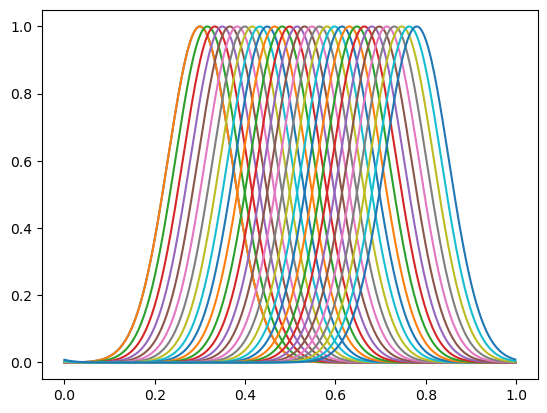

In [192]:
n = 512
h = 1/n
T = 0.4
num_time_points = 30
t_vals = np.linspace(0, T, num_time_points)
A = np.zeros((n,n), dtype=np.complex128)

for i in range(n):
#     A[i,(i+1)%n] = (1.2 + np.sin(2 * np.pi * (i)/n)) / h
#     A[i,i] = -(1.2 + np.sin(2 * np.pi * (i)/n)) / h
    A[i,(i-1)%n] = (1.2) / (2 * h)
    A[(i-1)%n, i] = -(1.2) / (2 * h)

print(A)

# plt.matshow(A.imag)
# plt.show()
x = np.linspace(0, 1, n, endpoint=False)

psi_0 = np.exp(-((x - 0.3)/0.1) ** 2)
plt.plot(x, psi_0)

psi = expm_multiply(A, psi_0, start=0, stop=T, num=num_time_points)

for i in range(num_time_points):
    # plt.plot(x, psi[i].imag)
    plt.plot(x, psi[i])

[[-1228.8+0.j     0. +0.j     0. +0.j ...     0. +0.j     0. +0.j
   1228.8+0.j]
 [ 1228.8+0.j -1228.8+0.j     0. +0.j ...     0. +0.j     0. +0.j
      0. +0.j]
 [    0. +0.j  1228.8+0.j -1228.8+0.j ...     0. +0.j     0. +0.j
      0. +0.j]
 ...
 [    0. +0.j     0. +0.j     0. +0.j ... -1228.8+0.j     0. +0.j
      0. +0.j]
 [    0. +0.j     0. +0.j     0. +0.j ...  1228.8+0.j -1228.8+0.j
      0. +0.j]
 [    0. +0.j     0. +0.j     0. +0.j ...     0. +0.j  1228.8+0.j
  -1228.8+0.j]]


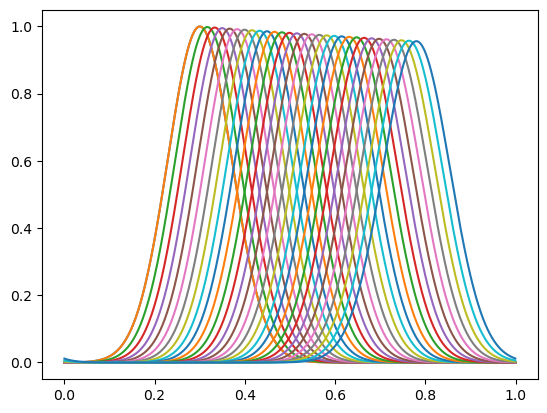

In [194]:
n = 1024
h = 1/n
T = 0.4
num_time_points = 30
t_vals = np.linspace(0, T, num_time_points)
A = np.zeros((n,n), dtype=np.complex128)

for i in range(n):
#     A[i,(i+1)%n] = (1.2 + np.sin(2 * np.pi * (i)/n)) / h
#     A[i,i] = -(1.2 + np.sin(2 * np.pi * (i)/n)) / h
    A[i,(i-1)%n] = (1.2) / h
    A[i,i] = -(1.2) / h

print(A)

# plt.matshow(A.imag)
# plt.show()
x = np.linspace(0, 1, n, endpoint=False)

psi_0 = np.exp(-((x - 0.3)/0.1) ** 2)
plt.plot(x, psi_0)

psi = expm_multiply(A, psi_0, start=0, stop=T, num=num_time_points)

for i in range(num_time_points):
    # plt.plot(x, psi[i].imag)
    plt.plot(x, psi[i])